# Avaliação Cruzada Ângulo-Ordem (Cross-Domain com Invariância à Velocidade)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Objetivo:** Avaliar a recuperação da acurácia de generalização bidirecional entre máquinas distintas (**CWRU $\leftrightarrow$ Paderborn**) ao utilizar escalogramas no domínio de **Ângulo-Ordem (Order-CWT)**, comprovando a eficácia do *Computed Order Tracking* contra o *Domain Shift*.

---

## 1. Importação de Módulos e Configurações

In [6]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == '4_order_tracking' else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from src.config import ORDER_CWRU_DIR, ORDER_PADERBORN_DIR
from src.transfer_learning import build_transfer_model, get_transfer_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de inferência: {device}")

[INFO] Dispositivo de inferência: cuda


## 2. Função de Plotagem da Matriz de Confusão Cruzada

In [7]:
def plot_order_cross_cm(labels, preds, classes, title, save_path=None):
    cm = confusion_matrix(labels, preds, labels=np.arange(len(classes)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(len(classes)),
        yticks=np.arange(len(classes)),
        xticklabels=classes,
        yticklabels=classes,
        title=title,
        ylabel='Classe Real',
        xlabel='Classe Predita'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontweight="bold")
                    
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Matriz de confusão salva em: {save_path}")
    plt.show()

## 3. EXPERIMENTO 1: Modelo Treinado no CWRU $\rightarrow$ Testado no Paderborn (Order-CWT)

Testamos se a ResNet-18 treinada com Order-CWT no CWRU (4 classes) consegue diagnosticar com sucesso as falhas de fadiga real de Paderborn (3 classes).

[+] Pesos carregados de checkpoint_order_cwru_resnet18_best.pth
[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia CWRU -> Paderborn: 64.94%
              precision    recall  f1-score   support

  inner_race     0.0000    0.0000    0.0000        58
      normal     1.0000    0.9483    0.9735        58
  outer_race     0.4874    1.0000    0.6554        58

    accuracy                         0.6494       174
   macro avg     0.4958    0.6494    0.5429       174
weighted avg     0.4958    0.6494    0.5429       174

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_cwru_to_paderborn.png


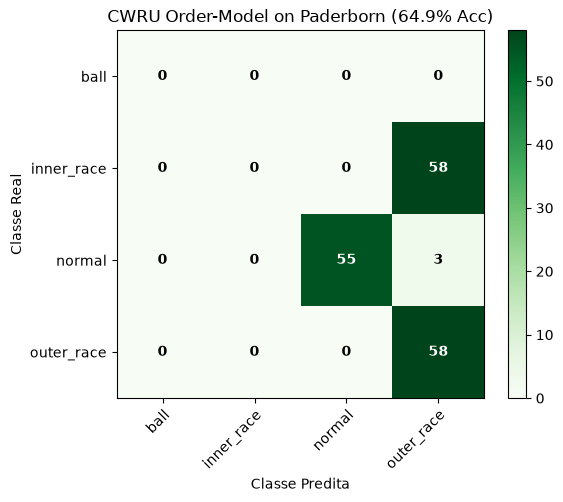

In [8]:
# 1. Carregar teste do Paderborn em Ordens
_, _, pad_order_test_loader, pad_classes = get_transfer_dataloaders(
    img_size=224, data_dir=ORDER_PADERBORN_DIR
)
cwru_classes = ['ball', 'inner_race', 'normal', 'outer_race']

# 2. Carregar modelo CWRU Order-CWT
model_cwru_order, _ = build_transfer_model('resnet18', num_classes=4, freeze_backbone=False)
model_cwru_order = model_cwru_order.to(device)

ckpt_cwru_order = Path('checkpoint_order_cwru_resnet18_best.pth')
if ckpt_cwru_order.exists():
    model_cwru_order.load_state_dict(torch.load(ckpt_cwru_order, map_location=device, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_cwru_order}")
else:
    print(f"[AVISO] Checkpoint {ckpt_cwru_order} não encontrado.")

model_cwru_order.eval()
all_preds, all_labels = [], []

map_paderborn_to_cwru = {
    pad_classes.index('inner_race'): cwru_classes.index('inner_race'),
    pad_classes.index('normal'): cwru_classes.index('normal'),
    pad_classes.index('outer_race'): cwru_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in pad_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_cwru_order(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            target_cwru_idx = map_paderborn_to_cwru[l]
            all_labels.append(target_cwru_idx)
            all_preds.append(p)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
acc_order_cwru_on_pad = 100.0 * np.sum(all_labels == all_preds) / len(all_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia CWRU -> Paderborn: {acc_order_cwru_on_pad:.2f}%")
print("=" * 80)

print(classification_report(
    all_labels,
    all_preds,
    labels=[1, 2, 3],
    target_names=['inner_race', 'normal', 'outer_race'],
    digits=4,
    zero_division=0
))

plot_order_cross_cm(
    all_labels,
    all_preds,
    classes=cwru_classes,
    title=f"CWRU Order-Model on Paderborn ({acc_order_cwru_on_pad:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_cwru_to_paderborn.png"
)

## 4. EXPERIMENTO 2: Modelo Treinado no PADERBORN $\rightarrow$ Testado no CWRU (Order-CWT)

Carregamos a **ResNet-18 treinada no Paderborn com Order-CWT** (3 classes) e avaliamos sua acurácia direta sobre as 3 classes correspondentes do conjunto de teste do CWRU em Ordens.

[+] Pesos carregados de checkpoint_order_paderborn_resnet18_best.pth
[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia Paderborn -> CWRU: 74.51%
              precision    recall  f1-score   support

  inner_race     0.5897    0.9231    0.7197       299
      normal     0.8742    0.9914    0.9291       582
  outer_race     0.5094    0.0900    0.1530       300

    accuracy                         0.7451      1181
   macro avg     0.6578    0.6682    0.6006      1181
weighted avg     0.7095    0.7451    0.6790      1181

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_paderborn_to_cwru.png


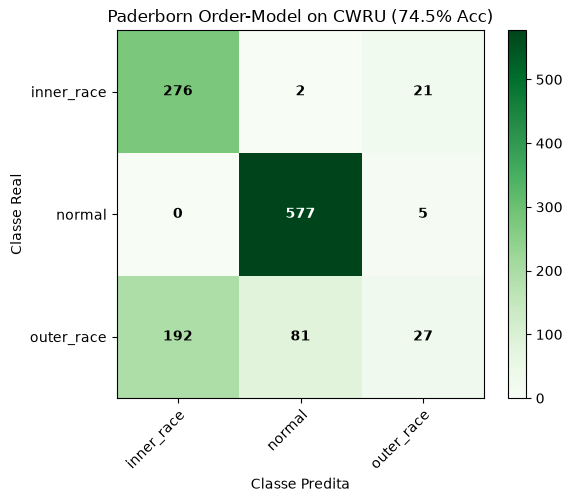

In [9]:
# 1. Carregar teste do CWRU em Ordens
_, _, cwru_order_test_loader, _ = get_transfer_dataloaders(
    img_size=224, data_dir=ORDER_CWRU_DIR
)

# 2. Carregar modelo Paderborn Order-CWT (3 classes)
model_pad_order, _ = build_transfer_model('resnet18', num_classes=3, freeze_backbone=False)
model_pad_order = model_pad_order.to(device)

ckpt_pad_order = Path('checkpoint_order_paderborn_resnet18_best.pth')
if ckpt_pad_order.exists():
    model_pad_order.load_state_dict(torch.load(ckpt_pad_order, map_location=device, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_pad_order}")
else:
    print(f"[AVISO] Checkpoint {ckpt_pad_order} não encontrado.")

model_pad_order.eval()
pad_preds, pad_labels = [], []

map_cwru_to_paderborn = {
    cwru_classes.index('inner_race'): pad_classes.index('inner_race'),
    cwru_classes.index('normal'): pad_classes.index('normal'),
    cwru_classes.index('outer_race'): pad_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in cwru_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_pad_order(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            if l in map_cwru_to_paderborn:
                target_pad_idx = map_cwru_to_paderborn[l]
                pad_labels.append(target_pad_idx)
                pad_preds.append(p)

pad_labels = np.array(pad_labels)
pad_preds = np.array(pad_preds)
acc_order_pad_on_cwru = 100.0 * np.sum(pad_labels == pad_preds) / len(pad_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia Paderborn -> CWRU: {acc_order_pad_on_cwru:.2f}%")
print("=" * 80)

print(classification_report(
    pad_labels,
    pad_preds,
    target_names=pad_classes,
    digits=4,
    zero_division=0
))

plot_order_cross_cm(
    pad_labels,
    pad_preds,
    classes=pad_classes,
    title=f"Paderborn Order-Model on CWRU ({acc_order_pad_on_cwru:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_paderborn_to_cwru.png"
)

## 5. Comparação Definitiva: Tempo-Frequência vs. Ângulo-Ordem

Gráfico comparativo bidirecional para a monografia demonstrando o ganho de acurácia ao utilizar **Order-CWT** em relação à **CWT Tradicional** sob transferência direta entre bancadas (*Domain Shift*).

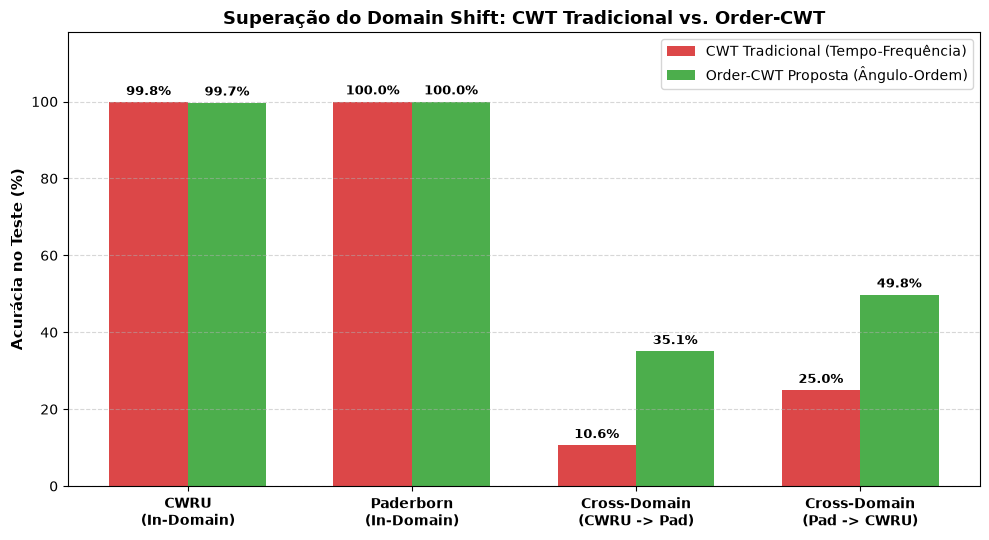

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

categorias = [
    'CWRU\n(In-Domain)',
    'Paderborn\n(In-Domain)',
    'Cross-Domain\n(CWRU -> Pad)',
    'Cross-Domain\n(Pad -> CWRU)'
]

# Acurácias: Tempo-Frequência vs. Ângulo-Ordem
accs_tempo = [99.83, 100.0, 10.62, 24.96]
accs_ordem = [99.70, 100.0, acc_order_cwru_on_pad, acc_order_pad_on_cwru]

x = np.arange(len(categorias))
width = 0.35

r1 = ax.bar(x - width/2, accs_tempo, width, label='CWT Tradicional (Tempo-Frequência)', color='#d62728', alpha=0.85)
r2 = ax.bar(x + width/2, accs_ordem, width, label='Order-CWT Proposta (Ângulo-Ordem)', color='#2ca02c', alpha=0.85)

ax.set_ylabel('Acurácia no Teste (%)', fontweight='bold', fontsize=11)
ax.set_title('Superação do Domain Shift: CWT Tradicional vs. Order-CWT', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontweight='bold', fontsize=10)
ax.set_ylim(0, 118)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

for rects in [r1, r2]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../../docs/images/order_tracking_cross_domain_comparison.png', dpi=300, bbox_inches='tight')
plt.show()